In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("D:\\dataset\\kn_ml\\Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


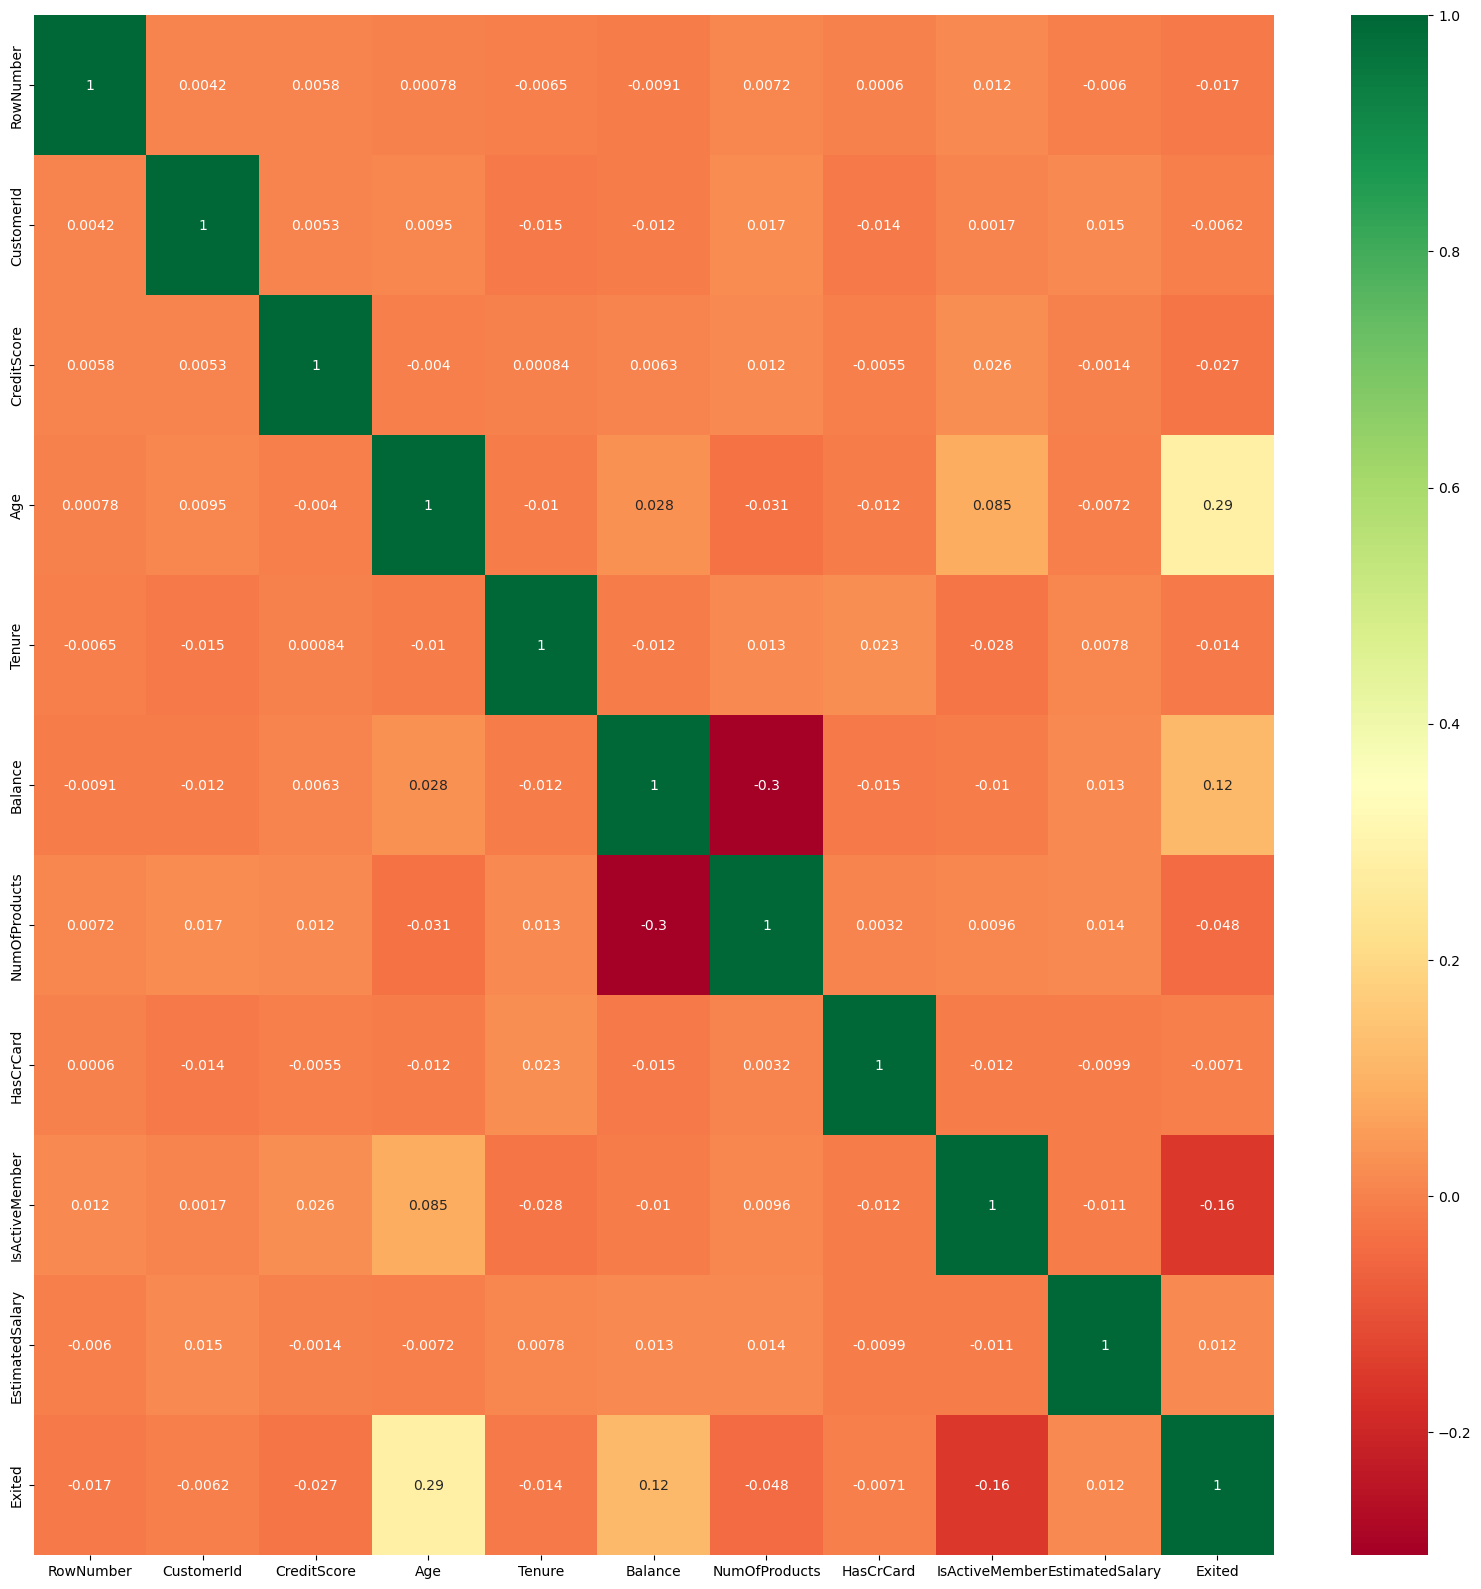

In [3]:
corrmat = df.corr(numeric_only = True)
top_corr_feature = corrmat.index
plt.figure(figsize = (20, 20))
g = sns.heatmap(df[top_corr_feature].corr(), annot = True, cmap = 'RdYlGn')
plt.show()

In [4]:
X = df.iloc[:, 3:13]
y = df.iloc[:, -1]

In [5]:
geography = pd.get_dummies(X['Geography'], drop_first = True)
geography.head()

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True


In [6]:
gender = pd.get_dummies(X['Gender'], drop_first = True)
gender.head()

,Male
0,False
1,False
2,False
3,False
4,False


In [7]:
X = X.drop(['Geography', 'Gender'], axis = 1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [8]:
X = pd.concat([X, geography, gender], axis = 1)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


### Hyper Parameter Optimization

In [9]:
# !pip install xgboost

In [10]:
params = {
'learning_rate' : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
'max_depth' : [3, 4, 5, 6, 8, 10, 12, 15],
'min_child_weight' : [1, 3, 5, 7],
'gamma' : [0.1, 0.2, 0.3, 0.4],
'colsample_bytree' : [0.3, 0.4, 0.5, 0.7]
}

In [11]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import xgboost

Randomized search algorithm will do permutation and combination of each and every value and try to find out which particular value is giving the highest accuracy 
- Also don't lower the value of learning rate lower than 0.05 otherwise it'll give overfitting condition

In [12]:
classifier = xgboost.XGBClassifier()

In [13]:
random_search = RandomizedSearchCV(classifier, param_distributions = params, n_iter = 5, scoring = 'roc_auc', n_jobs = -1, cv = 5, verbose = 3)

n_jobs for utilizing all the cores present inside your machines, cv for 5 different cross validation, verbose is for displaying the message of time it took to fit to perform and status of the jobs
To clean up those messy warning logs, replace silent=True with verbosity=0.
- verbosity=0: Silent
- verbosity=1: Warning
- verbosity=2: Info
- verbosity=3: Debug

In [14]:
def timer(start_time = None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print('\nTime taken: %i hours %i minutes %i seconds' % (thour, tmin, round(tsec, 2)))

In [15]:
from datetime import datetime
start_time = timer(None)
random_search.fit(X, y)
timer(start_time)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Time taken: 0 hours 0 minutes 21 seconds


In [16]:
print(random_search.best_estimator_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [17]:
random_search.best_params_

{'min_child_weight': 3,
 'max_depth': 5,
 'learning_rate': 0.15,
 'gamma': 0.2,
 'colsample_bytree': 0.4}

In [18]:
classifier = xgboost.XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
    colsample_bytree=0.5, gamma=0.4, learning_rate=0.1,max_delta_step=0, max_depth=6, 
    min_child_weight=7, missing=np.nan,    # FIX: Change None to np.nan
    n_estimators=100, n_jobs=1, objective='binary:logistic', random_state=0, reg_alpha=0, 
    reg_lambda=1, scale_pos_weight=1, verbosity=0,    # FIX: Replace silent=True with verbosity=0
    subsample=1
)

In [19]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(classifier, X, y, cv = 10)
score

array([0.878, 0.865, 0.87 , 0.866, 0.865, 0.856, 0.862, 0.877, 0.859,
       0.855])

In [20]:
score.mean()

np.float64(0.8653000000000001)